# Interpolation in higher dimensions

In [1]:
# initialization
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

As it turns out, the concept of linear interpolation can be extended to $n > 1$ dimensions. However, the proper generalization differs depending on whether data exist on a regular (or rectangular) grid or not. Consequently, there is a different interface for each case.

## Intepolating from a regular grid

Let's look at our sea surface temperature data again, this time as a function of both latitude and longitude

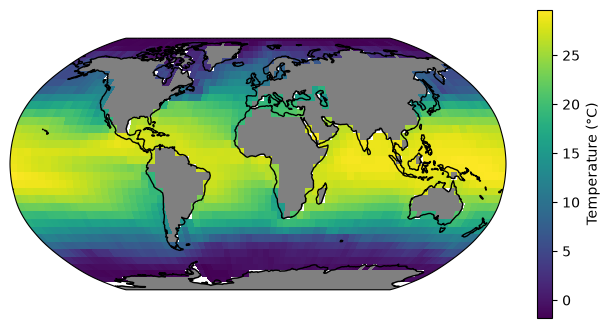

In [2]:
woa23 = xr.open_dataset("data/woa23_decav_t00_5d.nc", decode_times=False)
sst = woa23["t_mn"].sel(depth=0, method="nearest").squeeze()
sst_lat = sst.coords["lat"].values
sst_lon = sst.coords["lon"].values
sst_val = sst.values

fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(projection=ccrs.Robinson())

im = ax.pcolormesh(sst_lon, sst_lat, sst_val, transform=ccrs.PlateCarree())
cb = fig.colorbar(im)

cb.set_label("Temperature (°C)")

ax.add_feature(cfeature.LAND, color="gray")
ax.coastlines()

plt.show(fig)

Let's focus on a patch of the ocean near the Axial Seamount (approx. 46°N, 130°W)

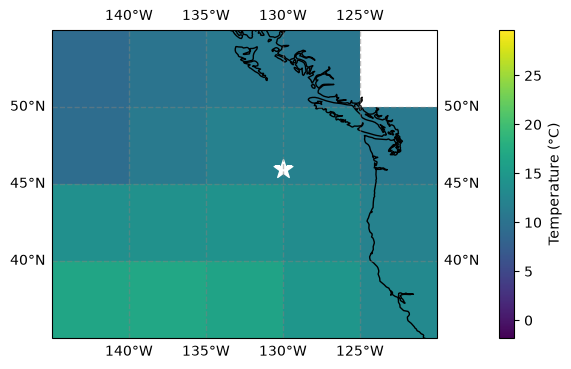

In [3]:
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(projection=ccrs.PlateCarree())

ax.set_extent([-145, -120, 35, 55], crs=ccrs.PlateCarree())

ax.coastlines()

im = ax.pcolormesh(sst_lon, sst_lat, sst_val, transform=ccrs.PlateCarree())
cb = fig.colorbar(im, pad=0.1)

ax.scatter(-130, 46, marker="*", color="white", s=200)

cb.set_label("Temperature (°C)")

gl = ax.gridlines(
    crs=ccrs.PlateCarree(), draw_labels=True, 
    linewidth=1, color='gray', alpha=0.5, linestyle='--'
)
gl.xlocator = mticker.FixedLocator(np.arange(-145, 120, 5))
gl.ylocator = mticker.FixedLocator(np.arange(35, 55, 5))
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

plt.show(fig)

Notice that we have data defined on a regular grid (the white tile in the plot corresponds to an `NaN` value in the data). Now let's use linear interpolation to assign a sea surface temperature at the location of the seamount. The function we need is `RegularGridInterpolator` from the `scipy.interpolate` submodule:

In [4]:
from scipy.interpolate import RegularGridInterpolator

The `RegularGridInterpolator` function takes two mandatory arguments. The first argument is a tuple of numpy arrays specifying the coordinates of the dimensions of the data, while the second argument is the values of the data at the specified coordinates. In our case, the data is two-dimensional, with rows (axis 0) corresponding to different latitudes and columns (axis 1) corresponding to different longitudes. Thus, the first argument should take the form (_latitudes_, _longitudes_). Hence, our code is:

In [5]:
reg_interp = RegularGridInterpolator((sst_lat, sst_lon), sst_val)

The output of `RegularGridInterpolator` is a function. To call this function, we supply a numpy array for which the last axis corresponds to the coordinates of a single point to evaluate the interpolator at. Thus, for the Axial Seamount, we supply:

In [6]:
reg_interp(np.array([46, -130]))

array([12.4276814])

in other words, the interpolated sea surface temperature at the seamount is 12.43°C

As before, it is possible to evaluate the interpolator at a collection of coordinates in one go. As an example, let's say we want to upsample the region shown in the above plot at 1° resolution, we first construct the input argument to `reg_interp` using a combination of `np.meshgrid` and `np.stack`:

In [7]:
new_lon = np.arange(-145, -119.9, 1)
new_lat = np.arange(35, 55.1, 1)

new_coords = np.stack(np.meshgrid(new_lat, new_lon, indexing='ij'), axis=-1)

In the above, `np.meshgrid` is used to create two two-dimensional arrays from `new_lon` and `new_lat`, and `np.stack` assemble them into a single 3-axes array. The `indexing` argument and the `axis` argument are set so that when `new_coords` is fed into `reg_interp` the output will have latitudes as rows and longitudes as columns.

All it remains is to feed `new_coords` into `reg_interp`:

In [8]:
new_sst = reg_interp(new_coords)

Visualizing the results:

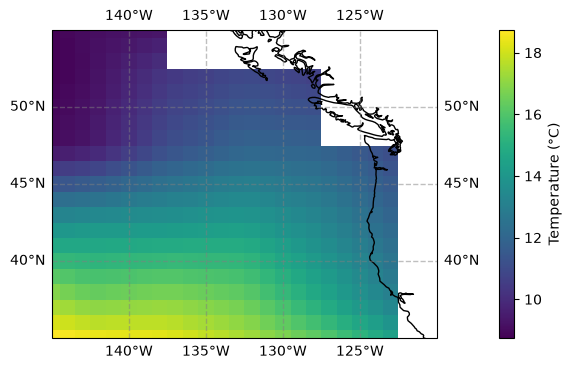

In [9]:
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(projection=ccrs.PlateCarree())

ax.set_extent([-145, -120, 35, 55], crs=ccrs.PlateCarree())

ax.coastlines()

im = ax.pcolormesh(new_lon, new_lat, new_sst, transform=ccrs.PlateCarree())
cb = fig.colorbar(im, pad=0.1)

cb.set_label("Temperature (°C)")

gl = ax.gridlines(
    crs=ccrs.PlateCarree(), draw_labels=True, 
    linewidth=1, color='gray', alpha=0.5, linestyle='--'
)
gl.xlocator = mticker.FixedLocator(np.arange(-145, 120, 5))
gl.ylocator = mticker.FixedLocator(np.arange(35, 55, 5))
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

plt.show(fig)

## Intepolating from unstructured data

For interpolating from unstructured (i.e., not gridded) data, let's consider the [International Comprehensive Ocean-Atmosphere Data Set (ICOADS)](https://www.ncei.noaa.gov/products/international-comprehensive-ocean-atmosphere-data-set). The data on this dataset comes from surface marine observational records from ships, buoys, and other platform types. Due to the nature of the observations, the raw data do not reside on a regular grid at all.

To see this, consider the sea surface temperature measurements from this dataset. The data we used can be found [here](https://github.com/OCEAN-215-2026/preclass/tree/main/week_10/data/ICOADS_SST_2010-06.nc). Opening the dataset in xarray and converting it into a pandas dataframe, we obtain:

In [10]:
obs_SST = xr.open_dataset("data/ICOADS_SST_2010-06.nc").to_dataframe()
obs_SST

,SST,time,lat,lon
obs,,,,
0,13.200000,2010-05-29 00:00:00.000000,54.000000,8.200000
1,9.500000,2010-05-29 02:00:00.000013,57.400002,20.700001
2,11.800000,2010-05-29 03:00:00.000000,54.200001,7.900000
3,12.700000,2010-05-29 03:59:59.999987,55.000000,7.300000
4,16.100000,2010-05-29 06:59:59.999987,54.299999,5.800000
...,...,...,...,...
1653433,17.299999,2010-06-27 23:58:47.999988,-35.110001,318.130005
1653434,18.400000,2010-06-27 23:58:47.999988,-36.939999,311.130005
1653435,13.600000,2010-06-27 23:58:47.999988,-39.959999,319.329987


For illustrative purpose, let's narrow down to a particular patch of the North Atlantic Ocean, and focus on a narrow one-hour window:

In [11]:
obs_sub = obs_SST[
    (obs_SST["lat"] < 50) & (obs_SST["lat"] > 25) &
    (obs_SST["lon"] > 315) & (obs_SST["lon"] < 335) &
    (obs_SST["time"] > pd.to_datetime("2010-06-15 11:00")) & 
    (obs_SST["time"] < pd.to_datetime("2010-06-15 12:00"))
]

Making a scatter plot of the observationss, using color to indicate temperature, we get:

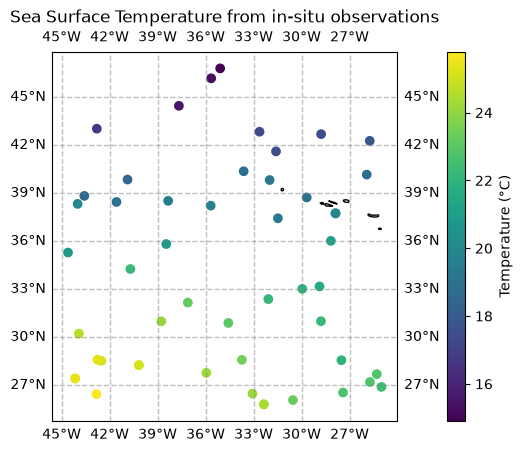

In [12]:
lat = obs_sub["lat"].values
lon = obs_sub["lon"].values
sst = obs_sub["SST"].values

fig = plt.figure()
ax = fig.add_subplot(projection=ccrs.PlateCarree())

im = ax.scatter(lon, lat, c = sst, transform=ccrs.PlateCarree())
ax.coastlines()

cb = fig.colorbar(im, pad=0.1)
cb.set_label("Temperature (°C)")

ax.set_title("Sea Surface Temperature from in-situ observations")

gl = ax.gridlines(
    crs=ccrs.PlateCarree(), draw_labels=True,
    linewidth=1, color='gray', alpha=0.5, linestyle='--'
)


plt.show(fig)

We see that while the data is not on a grid, the observations are sufficiently dense that we can identify some general trend. The denseness of data also make it feasible to generate gridded synthetic data based on the actual observations.

To interpolate the unstructured data, we need to use a different scipy function from the `scipy.interpolate` submodule, namely the `LinearNDInterpolator()` function, which we import via:

In [13]:
from scipy.interpolate import LinearNDInterpolator

The `LinearNDInterpolator` function has 2 required arguments. The first is a numpy array of shape (N, d) containing the coordinates of the data points (here N is the number of data points and d is the dimensionality of the coordinate system). The second is the corresponding 1D numpy array of values. Thus, in our case:

In [14]:
irreg_interp = LinearNDInterpolator(
    obs_sub.loc[:, ["lat", "lon"]].values, obs_sub["SST"].values
)

Now we create the regular grid for which the interpolated values will be computed:

In [15]:
new_lon = np.arange(315, 335.1, 1)
new_lat = np.arange(25, 50.1, 1)

new_coords = np.stack(np.meshgrid(new_lat, new_lon, indexing='ij'), axis=-1)

From which we can compute the interpolated values:

In [16]:
new_SST = irreg_interp(new_coords)

Let's plot the gridded interpolated data, together with the original sampling locations marked in gray filled circles:

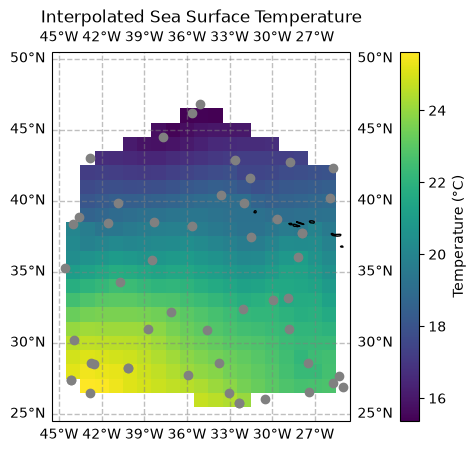

In [17]:
fig = plt.figure()
ax = fig.add_subplot(projection=ccrs.PlateCarree())

im = ax.pcolormesh(new_lon, new_lat, new_SST, transform=ccrs.PlateCarree())

cb = fig.colorbar(im, pad=0.1)
cb.set_label("Temperature (°C)")

pts = ax.scatter(lon, lat, c="gray", transform=ccrs.PlateCarree())

ax.coastlines()

ax.set_title("Interpolated Sea Surface Temperature")

gl = ax.gridlines(
    crs=ccrs.PlateCarree(), draw_labels=True,
    linewidth=1, color='gray', alpha=0.5, linestyle='--'
)

plt.show(fig)

We note that the color grid contains a number of white tiles. That's because a number of the grid points fall onto the **exterior** of the collection of actual observations, and thus evaluated to `NaN` by the interpolating function.